In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('ai_company_adoption.csv')
df.head(5)

,response_id,company_id,survey_year,quarter,country,region,industry,company_size,num_employees,annual_revenue_usd_millions,...,productivity_change_percent,jobs_displaced,jobs_created,reskilled_employees,revenue_growth_percent,cost_reduction_percent,innovation_score,customer_satisfaction,survey_source,data_collection_method
0,1,COMP-00001,2023,Q1,Italy,Europe,Education,Startup,57,48.31,...,2.65,1,1,3,2.52,9.45,53,5.20,WEF Survey,API Scrape
1,2,COMP-00001,2023,Q2,Italy,Europe,Education,Startup,57,48.31,...,5.77,2,2,5,4.77,0.00,51,6.98,McKinsey Report,Phone Interview
2,3,COMP-00001,2023,Q3,Italy,Europe,Education,Startup,57,48.31,...,6.94,3,3,2,12.87,9.74,40,4.12,Internal Corporate Survey,Research Compilation
3,4,COMP-00001,2023,Q4,Italy,Europe,Education,Startup,57,48.31,...,5.32,1,1,2,8.19,0.00,51,5.72,Internal Corporate Survey,Research Compilation
4,5,COMP-00001,2024,Q1,Italy,Europe,Education,Startup,57,48.31,...,6.32,2,3,6,11.30,9.02,43,6.31,McKinsey Report,Research Compilation


In [4]:
df.shape

(150000, 43)

In [5]:
df.columns

Index(['response_id', 'company_id', 'survey_year', 'quarter', 'country',
       'region', 'industry', 'company_size', 'num_employees',
       'annual_revenue_usd_millions', 'company_founding_year', 'company_age',
       'company_age_group', 'ai_adoption_rate', 'ai_adoption_stage',
       'years_using_ai', 'ai_primary_tool', 'num_ai_tools_used', 'ai_use_case',
       'ai_projects_active', 'ai_training_hours', 'ai_budget_percentage',
       'ai_maturity_score', 'ai_failure_rate', 'ai_investment_per_employee',
       'regulatory_compliance_score', 'data_privacy_level',
       'ai_ethics_committee', 'ai_risk_management_score',
       'remote_work_percentage', 'employee_satisfaction_score',
       'task_automation_rate', 'time_saved_per_week',
       'productivity_change_percent', 'jobs_displaced', 'jobs_created',
       'reskilled_employees', 'revenue_growth_percent',
       'cost_reduction_percent', 'innovation_score', 'customer_satisfaction',
       'survey_source', 'data_collection_meth

In [6]:
# we selected only those columns that are related to AI adoption and growth of the company not those that are related to employee

df = df[['company_id','industry','country','company_size','annual_revenue_usd_millions',
'ai_adoption_rate','ai_adoption_stage','years_using_ai','ai_maturity_score','ai_primary_tool','num_ai_tools_used',
'ai_projects_active','ai_budget_percentage','ai_failure_rate','ai_investment_per_employee','revenue_growth_percent',
'productivity_change_percent','cost_reduction_percent']]
df.head(5)

,company_id,industry,country,company_size,annual_revenue_usd_millions,ai_adoption_rate,ai_adoption_stage,years_using_ai,ai_maturity_score,ai_primary_tool,num_ai_tools_used,ai_projects_active,ai_budget_percentage,ai_failure_rate,ai_investment_per_employee,revenue_growth_percent,productivity_change_percent,cost_reduction_percent
0,COMP-00001,Education,Italy,Startup,48.31,30.57,pilot,3,0.224,ChatGPT,1,3,6.54,35.22,55392.29,2.52,2.65,9.45
1,COMP-00001,Education,Italy,Startup,48.31,27.25,pilot,4,0.174,ChatGPT,3,0,5.81,24.65,49210.79,4.77,5.77,0.00
2,COMP-00001,Education,Italy,Startup,48.31,31.54,pilot,2,0.266,Custom Internal AI,3,3,12.39,36.51,105011.76,12.87,6.94,9.74
3,COMP-00001,Education,Italy,Startup,48.31,11.02,pilot,2,0.123,Custom Internal AI,1,2,3.20,33.30,27157.71,8.19,5.32,0.00
4,COMP-00001,Education,Italy,Startup,48.31,33.39,pilot,7,0.363,ChatGPT,3,5,9.98,19.83,84622.90,11.30,6.32,9.02


In [7]:
df.shape

(150000, 18)

In [8]:
df.describe()

,annual_revenue_usd_millions,ai_adoption_rate,years_using_ai,ai_maturity_score,num_ai_tools_used,ai_projects_active,ai_budget_percentage,ai_failure_rate,ai_investment_per_employee,revenue_growth_percent,productivity_change_percent,cost_reduction_percent
count,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,1.500000e+05,150000.000000,150000.000000,150000.000000
mean,1180.345751,36.414726,4.931580,0.344675,2.315120,6.270693,9.509800,25.774337,6.872633e+04,4.606486,9.266996,4.814909
std,2391.471420,14.544096,2.429316,0.133820,0.946826,3.500142,3.837827,7.761027,8.603370e+04,5.318773,5.637067,3.383086
min,1.010000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000e+00,-5.000000,0.000000,0.000000
25%,33.880000,26.430000,3.000000,0.250000,2.000000,4.000000,6.880000,20.270000,2.129738e+04,0.780000,5.070000,2.120000
50%,184.160000,36.320000,5.000000,0.341000,2.000000,6.000000,9.430000,25.880000,4.324232e+04,4.480000,9.060000,4.620000
75%,444.150000,46.200000,7.000000,0.435000,3.000000,9.000000,12.080000,31.520000,8.161295e+04,8.240000,13.120000,7.130000
max,9996.730000,100.000000,10.000000,0.904000,6.000000,20.000000,25.000000,40.000000,1.898316e+06,30.000000,34.360000,20.790000


In [9]:
df.isnull().sum()

company_id                     0
industry                       0
country                        0
company_size                   0
annual_revenue_usd_millions    0
ai_adoption_rate               0
ai_adoption_stage              0
years_using_ai                 0
ai_maturity_score              0
ai_primary_tool                0
num_ai_tools_used              0
ai_projects_active             0
ai_budget_percentage           0
ai_failure_rate                0
ai_investment_per_employee     0
revenue_growth_percent         0
productivity_change_percent    0
cost_reduction_percent         0
dtype: int64

In [10]:
df.describe(include=object)

,company_id,industry,country,company_size,ai_adoption_stage,ai_primary_tool
count,150000,150000,150000,150000,150000,150000
unique,10000,9,30,3,4,6
top,COMP-09978,Technology,France,SME,partial,ChatGPT
freq,16,21107,5637,63867,78800,46103


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 18 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   company_id                   150000 non-null  object 
 1   industry                     150000 non-null  object 
 2   country                      150000 non-null  object 
 3   company_size                 150000 non-null  object 
 4   annual_revenue_usd_millions  150000 non-null  float64
 5   ai_adoption_rate             150000 non-null  float64
 6   ai_adoption_stage            150000 non-null  object 
 7   years_using_ai               150000 non-null  int64  
 8   ai_maturity_score            150000 non-null  float64
 9   ai_primary_tool              150000 non-null  object 
 10  num_ai_tools_used            150000 non-null  int64  
 11  ai_projects_active           150000 non-null  int64  
 12  ai_budget_percentage         150000 non-null  float64
 13 

In [12]:
df.duplicated()

0         False
1         False
2         False
3         False
4         False
          ...  
149995    False
149996    False
149997    False
149998    False
149999    False
Length: 150000, dtype: bool

In [13]:
df.columns

Index(['company_id', 'industry', 'country', 'company_size',
       'annual_revenue_usd_millions', 'ai_adoption_rate', 'ai_adoption_stage',
       'years_using_ai', 'ai_maturity_score', 'ai_primary_tool',
       'num_ai_tools_used', 'ai_projects_active', 'ai_budget_percentage',
       'ai_failure_rate', 'ai_investment_per_employee',
       'revenue_growth_percent', 'productivity_change_percent',
       'cost_reduction_percent'],
      dtype='object')

# Univariate Analysis

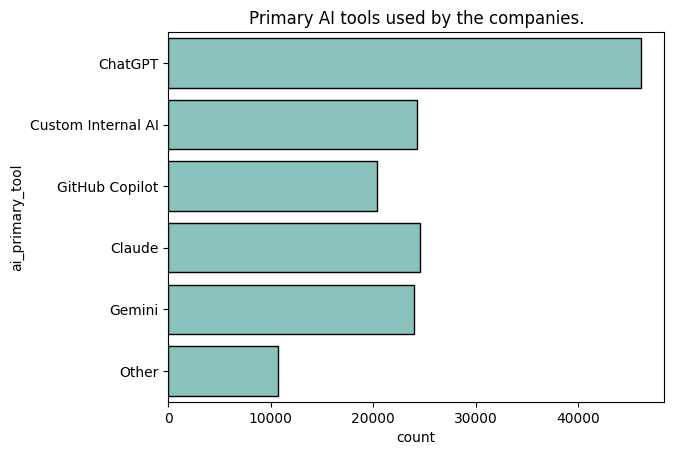

ai_primary_tool
ChatGPT               46103
Claude                24562
Custom Internal AI    24300
Gemini                23996
GitHub Copilot        20377
Other                 10662
Name: count, dtype: int64

In [14]:
sns.countplot(df["ai_primary_tool"],color = "#80CBC4",edgecolor="black")
plt.title("Primary AI tools used by the companies.")
plt.show()
df["ai_primary_tool"].value_counts()

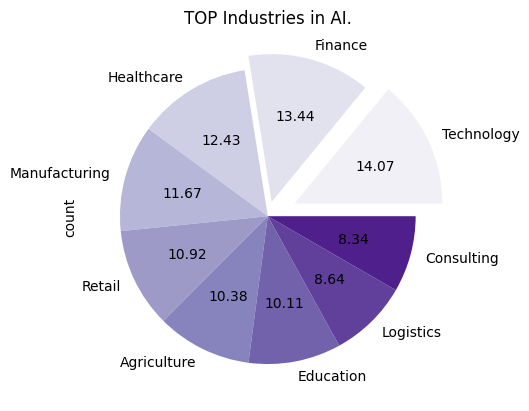

In [15]:
colors = sns.color_palette("Purples", 9)
explode = [0.2, 0.1, 0, 0, 0,0,0,0,0]
df["industry"].value_counts().plot(kind="pie",autopct="%.2f",colors=colors,explode=explode)
plt.title("TOP Industries in AI.")
plt.show()

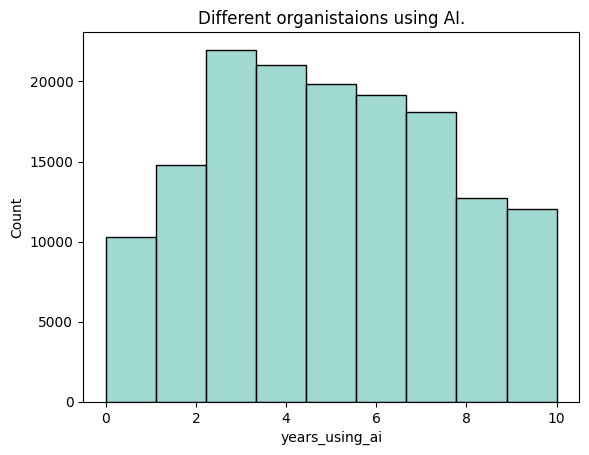

In [16]:
# Numerical features
sns.histplot(df["years_using_ai"],color="#80CBC4",bins = 9)
plt.title("Different organistaions using AI.")
plt.show()

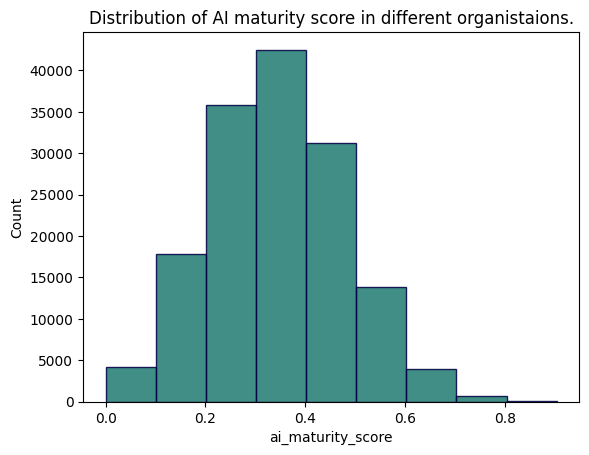

In [17]:
sns.histplot(df["ai_maturity_score"],color="#00695C",edgecolor = "#004D",bins = 9)
plt.title("Distribution of AI maturity score in different organistaions.")
plt.show()

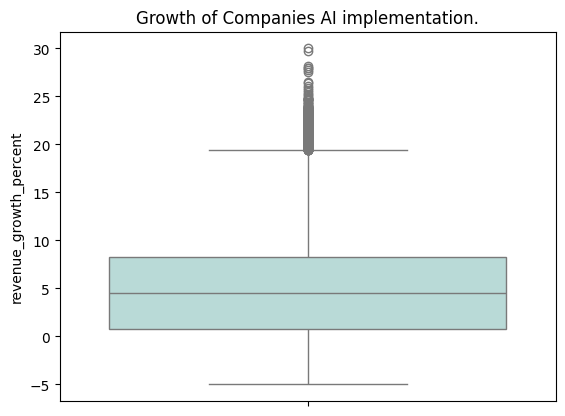

In [18]:
sns.boxplot(df['revenue_growth_percent'],color="#b3e0dc")
plt.title("Growth of Companies AI implementation.")
plt.show()

# Bivariate and Univariate Analysis 

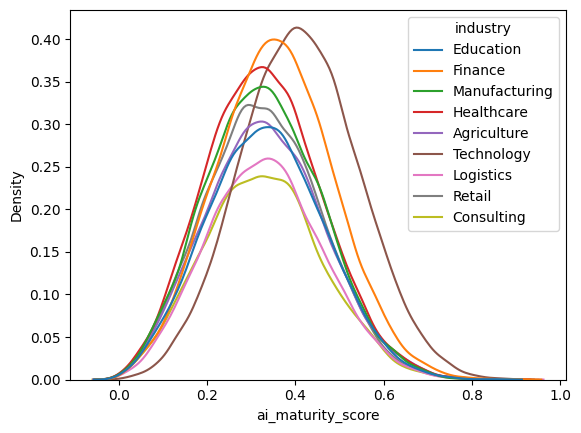

In [19]:
sns.kdeplot(df, x="ai_maturity_score",hue="industry")
plt.show()

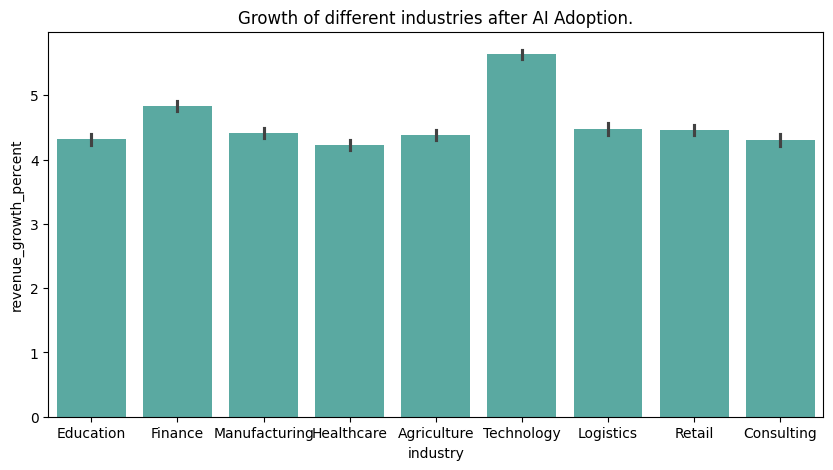

In [20]:
plt.figure(figsize=(10,5))
sample_df = df.sample(5000)
sns.barplot(data=sample_df, x=df['industry'],y=df['revenue_growth_percent'],color='#4DB6AC')
plt.title('Growth of different industries after AI Adoption.')
plt.show()

In [21]:
df[df['industry']=='Education']['revenue_growth_percent']

0          2.52
1          4.77
2         12.87
3          8.19
4         11.30
          ...  
149860     0.66
149861    11.74
149862    -5.00
149863    14.56
149864    12.04
Name: revenue_growth_percent, Length: 15172, dtype: float64

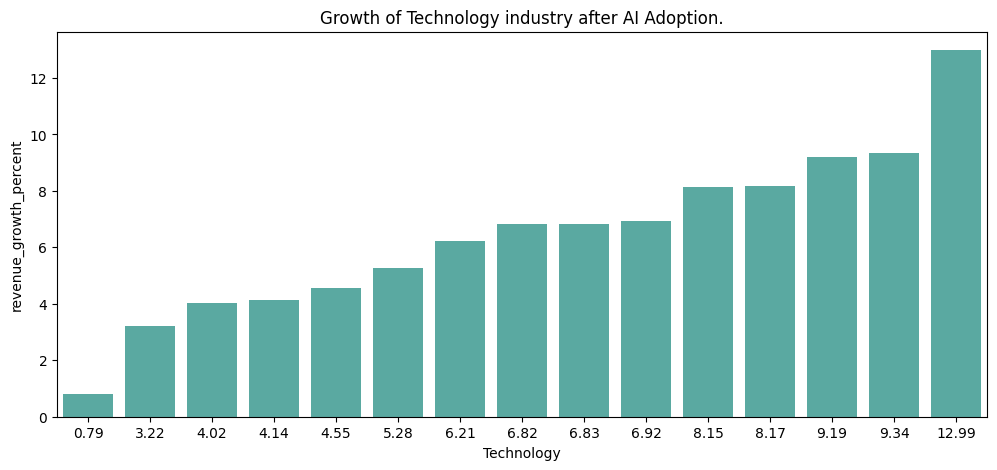

In [22]:
plt.figure(figsize=(12,5))
sample_df = df.sample(100)
sns.barplot(data=sample_df, x=sample_df[sample_df['industry']=='Technology']['revenue_growth_percent'],
            y=sample_df['revenue_growth_percent'],color='#4DB6AC')
plt.title('Growth of Technology industry after AI Adoption.')
plt.xlabel("Technology")
plt.ylabel("revenue_growth_percent")
plt.show()

# The Error Bar showing the spread of the data.

The Bar: Shows the average (mean) value of your data.

The Error Bar (SD): Shows how spread out the individual data points are around that average.


Short Error Bars: The data points are close to the average (little variation).

Tall/Wide Error Bars: The data points are spread far apart from the average (high variation).

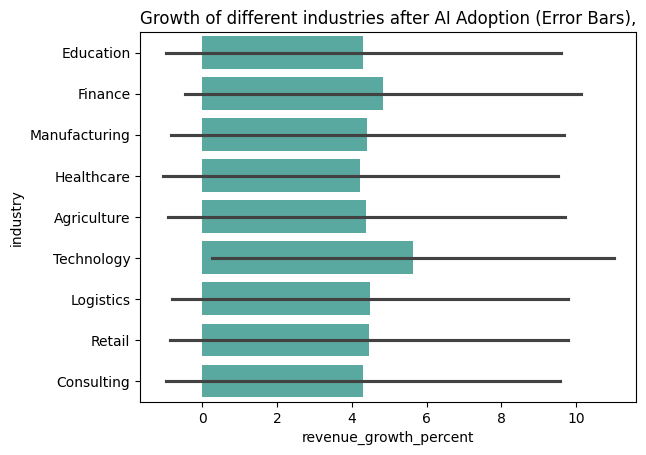

In [23]:
sns.barplot(data=df, x=df['revenue_growth_percent'],y=df['industry'],color='#4DB6AC',errorbar='sd')
plt.title('Growth of different industries after AI Adoption (Error Bars),')
plt.show()

In [24]:
df['company_size'].value_counts()

company_size
SME           63867
Startup       56685
Enterprise    29448
Name: count, dtype: int64

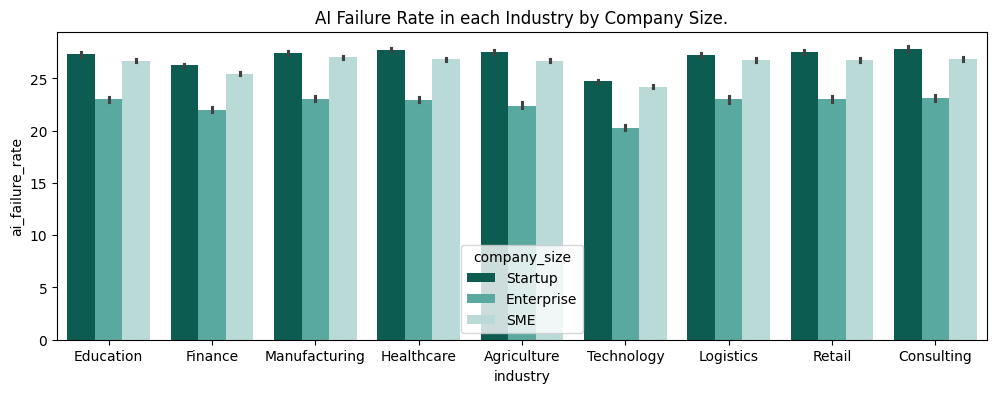

In [25]:
plt.figure(figsize=(12, 4))
palette = {
    "Startup": "#00695C",
    "Enterprise": "#4DB6AC",
    "SME": "#b3e0dc"
}
sns.barplot(x='industry', y='ai_failure_rate',palette=palette, data=df,hue="company_size")
plt.title("AI Failure Rate in each Industry by Company Size.")
plt.show()

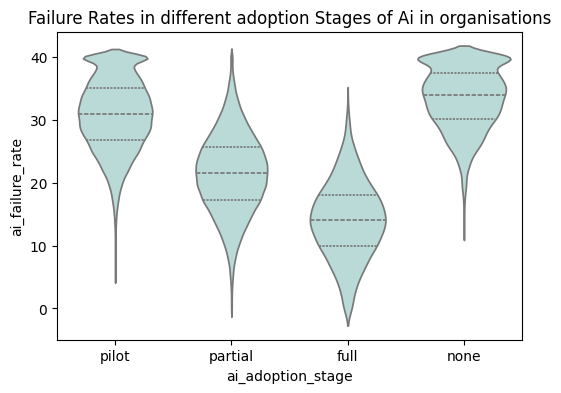

In [26]:
plt.figure(figsize=(6, 4))
sns.violinplot(x='ai_adoption_stage', y='ai_failure_rate', data=df, color="#b3e0dc", inner="quart")
plt.title("Failure Rates in different adoption Stages of Ai in organisations")
plt.show()

In [27]:
df.columns

Index(['company_id', 'industry', 'country', 'company_size',
       'annual_revenue_usd_millions', 'ai_adoption_rate', 'ai_adoption_stage',
       'years_using_ai', 'ai_maturity_score', 'ai_primary_tool',
       'num_ai_tools_used', 'ai_projects_active', 'ai_budget_percentage',
       'ai_failure_rate', 'ai_investment_per_employee',
       'revenue_growth_percent', 'productivity_change_percent',
       'cost_reduction_percent'],
      dtype='object')

In [28]:
df["ai_adoption_stage"].value_counts()

ai_adoption_stage
partial    78800
pilot      64317
none        5198
full        1685
Name: count, dtype: int64

<Axes: xlabel='ai_adoption_stage', ylabel='revenue_growth_percent'>

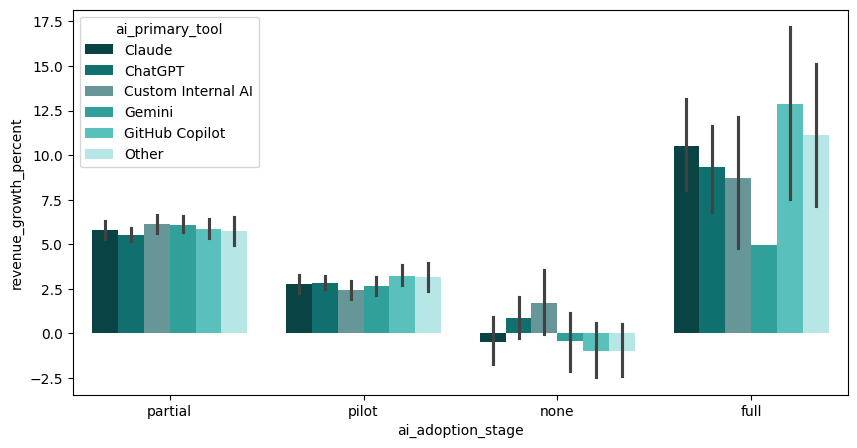

In [29]:
plt.figure(figsize=(10,5))
sample_df = df.sample(5000)
my_teals = ["#004d4d", "#008080", "#5f9ea0", "#20b2aa", "#48d1cc", "#afeeee"]
sns.barplot(data=sample_df,x="ai_adoption_stage",y="revenue_growth_percent",hue="ai_primary_tool",palette = my_teals)

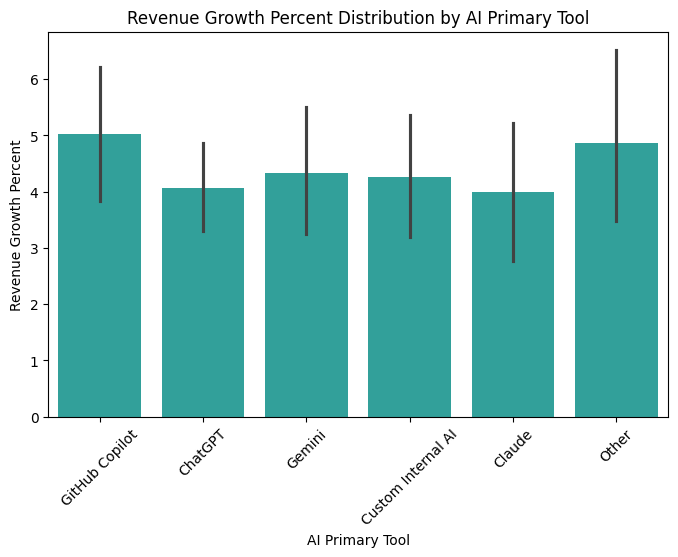

In [30]:
plt.figure(figsize=(8,5))
sample_df = df.sample(500)
sns.barplot(x='ai_primary_tool', y='revenue_growth_percent', data=sample_df, color="#20b2aa")
plt.xticks(rotation=45)
plt.title('Revenue Growth Percent Distribution by AI Primary Tool')
plt.xlabel('AI Primary Tool')
plt.ylabel('Revenue Growth Percent')
plt.show()

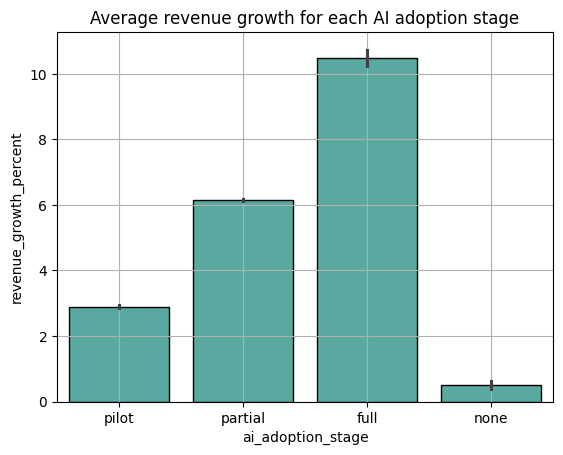

In [31]:
sns.barplot(data=df,x="ai_adoption_stage",y="revenue_growth_percent",color='#4DB6AC',edgecolor="Black")
plt.title("Average revenue growth for each AI adoption stage")
plt.grid()
plt.show()

In [32]:
df["ai_adoption_stage"].value_counts()

ai_adoption_stage
partial    78800
pilot      64317
none        5198
full        1685
Name: count, dtype: int64

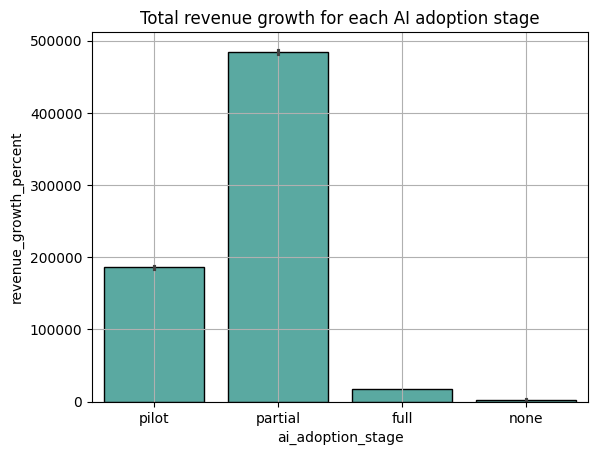

In [33]:
sns.barplot(data=df,x="ai_adoption_stage",y="revenue_growth_percent",estimator=sum,color='#4DB6AC',edgecolor="Black")
plt.title("Total revenue growth for each AI adoption stage")
plt.grid()
plt.show()

In [34]:
df.columns

Index(['company_id', 'industry', 'country', 'company_size',
       'annual_revenue_usd_millions', 'ai_adoption_rate', 'ai_adoption_stage',
       'years_using_ai', 'ai_maturity_score', 'ai_primary_tool',
       'num_ai_tools_used', 'ai_projects_active', 'ai_budget_percentage',
       'ai_failure_rate', 'ai_investment_per_employee',
       'revenue_growth_percent', 'productivity_change_percent',
       'cost_reduction_percent'],
      dtype='object')

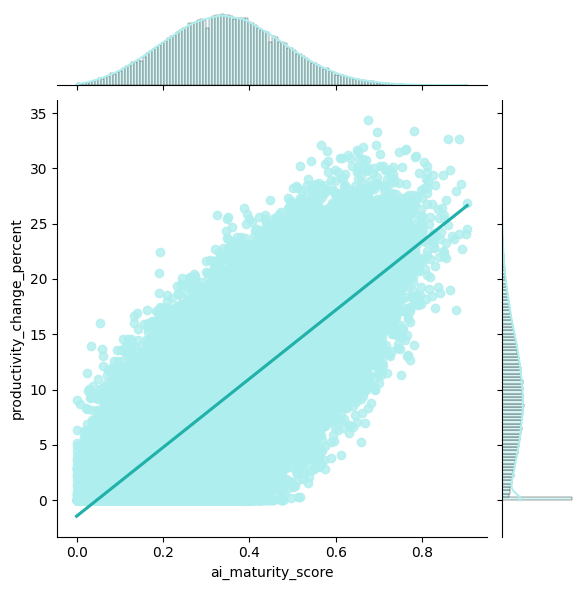

In [35]:
sns.jointplot(data=df, x='ai_maturity_score', y='productivity_change_percent', kind='reg',line_kws={"color": "#20b2aa"},color = '#afeeee')
plt.show()

In [36]:
df.head()

,company_id,industry,country,company_size,annual_revenue_usd_millions,ai_adoption_rate,ai_adoption_stage,years_using_ai,ai_maturity_score,ai_primary_tool,num_ai_tools_used,ai_projects_active,ai_budget_percentage,ai_failure_rate,ai_investment_per_employee,revenue_growth_percent,productivity_change_percent,cost_reduction_percent
0,COMP-00001,Education,Italy,Startup,48.31,30.57,pilot,3,0.224,ChatGPT,1,3,6.54,35.22,55392.29,2.52,2.65,9.45
1,COMP-00001,Education,Italy,Startup,48.31,27.25,pilot,4,0.174,ChatGPT,3,0,5.81,24.65,49210.79,4.77,5.77,0.00
2,COMP-00001,Education,Italy,Startup,48.31,31.54,pilot,2,0.266,Custom Internal AI,3,3,12.39,36.51,105011.76,12.87,6.94,9.74
3,COMP-00001,Education,Italy,Startup,48.31,11.02,pilot,2,0.123,Custom Internal AI,1,2,3.20,33.30,27157.71,8.19,5.32,0.00
4,COMP-00001,Education,Italy,Startup,48.31,33.39,pilot,7,0.363,ChatGPT,3,5,9.98,19.83,84622.90,11.30,6.32,9.02


# Inferential Statstical Analysis 

Inferential statistics uses data from a small, representative group (a sample) to make predictions, generalizations, or conclusions about a much larger group (a population). It goes beyond just describing data, using probability to estimate unknown population characteristics or test hypotheses

~ A graph is subjective—one person might see a "steep" slope, another might see a "slight" one. Stats provide an objective Confidence Interval. It tells you: "We are 95% sure the true revenue growth is between 4% and 8%.

Does AI adoption actually increase revenue?

Different industries have differnt maturity of AI?

Does AI maturity reduce failure rates?

# 1. AI Impact on Growth - coorelation/Regression
Null hypothesis: AI adoption has no effect on revenue growth,  Alternative hypothesis : AI adoption increases revenue growth

This function performs a statistical test to determine if the relationship between your two variables is strong enough to be considered "real" rather than just a result of random chance.

In [37]:
from scipy.stats import pearsonr

# Pearson's method for linear relationships and continuous data.
# Spearman's method for ordinal or non-linear relationships.

corr, p = pearsonr(df['ai_adoption_rate'], df['revenue_growth_percent'])

print("Correlation:", corr)
print("p-value:", p)
if p < 0.05:
    print("We are rejecting Null Hypothesis ")
else:
    print("We are accpeting Null Hypothesis ")

Correlation: 0.4068394337635401
p-value: 0.0
We are rejecting Null Hypothesis 


In [38]:
import statsmodels.api as sm

# Adding a constant for the intercept
X = sm.add_constant(df['ai_adoption_rate']) 
y = df['revenue_growth_percent']

# Ordinary Least Squares (OLS Regression)
model = sm.OLS(y, X).fit()
print(model.summary())

                              OLS Regression Results                              
Dep. Variable:     revenue_growth_percent   R-squared:                       0.166
Model:                                OLS   Adj. R-squared:                  0.166
Method:                     Least Squares   F-statistic:                 2.975e+04
Date:                    Tue, 14 Apr 2026   Prob (F-statistic):               0.00
Time:                            16:00:06   Log-Likelihood:            -4.4996e+05
No. Observations:                  150000   AIC:                         8.999e+05
Df Residuals:                      149998   BIC:                         8.999e+05
Df Model:                               1                                         
Covariance Type:                nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------


# AI adoption explains 16.6% of the variance in revenue growth.

It proves AI is a definitive driver of growth, but it acknowledges that the other 83.4% of growth is driven by
things like market demand, interest rates, competition, and leadership.

Having 150,000 observations is a "double-edged sword." While it makes our results incredibly reliable,
it also creates a phenomenon known as "The Large Sample Trap."

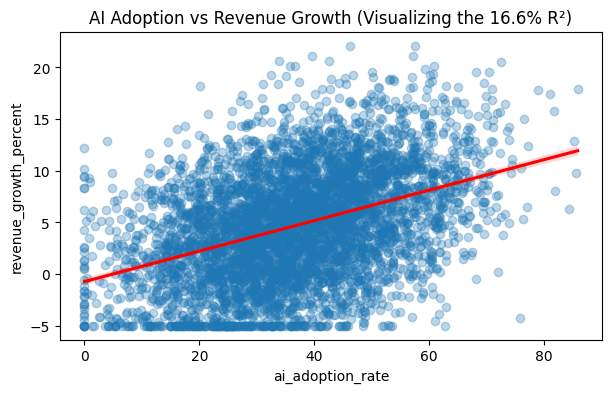

In [39]:
plt.figure(figsize=(7, 4))
# We sample 5000 points so the plot isn't too crowded
df_sample = df.sample(5000) 
sns.regplot(data=df_sample, x='ai_adoption_rate', y='revenue_growth_percent', 
            scatter_kws={'alpha':0.3}, line_kws={'color':'red'})

plt.title('AI Adoption vs Revenue Growth (Visualizing the 16.6% R²)')
plt.show()

# 2. Industry Differences in AI Maturity - ANNOVA
Null hypothesis: All industries have same AI maturity

Alternative hypothesis: At least one industry differs

We want to know if some industries are significantly "more mature" than others.

In [40]:
import scipy.stats as stats

# maturity scores for each industry group 
groups = [df[df['industry'] == ind]['ai_maturity_score'] for ind in df['industry'].unique()]

f_stat, p_val = stats.f_oneway(*groups)

print(f"F-Statistic: {f_stat}")
print(f"P-Value: {p_val}")

F-Statistic: 845.5825958537195
P-Value: 0.0


An F-statistic of 845 is huge. It confirms that "Industry" is not just a minor factor;
it is a dominant driver of AI maturity.

Since we have 150,000 observations, our F-statistic is boosted by our high volume of data.
However, even with large data, 845 is a very "clean" result. It suggests that if you were to pick a company at random,
knowing its Industry gives you a very strong head start in guessing its AI Maturity Score.

An F-score of 845 shows that Industry is a structural driver. * It means that the difference between being a "Retail" company and a "Tech" company isn't just a minor detail—it is one of the most important predictors of how mature a company's AI strategy will be.

Some industries have successfully "cracked the code" on AI, while others are fundamentally lagging. It suggests that AI adoption isn't happening at the same speed across the economy—it’s happening in waves, industry by industry.

C:\Users\KHUSHI COMPUTERS\AppData\Local\Temp\ipykernel_8264\596691950.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='industry', y='ai_maturity_score', order=industry_order, palette='viridis')


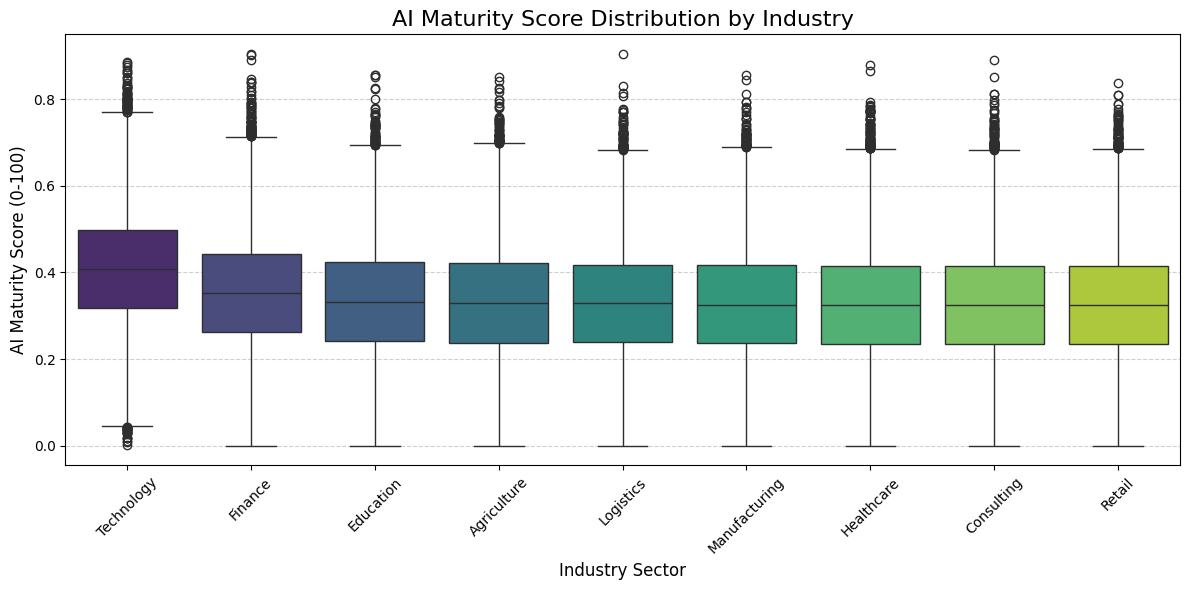

In [41]:
plt.figure(figsize=(12, 6))

# Sort industries by their median AI Maturity Score for better readability
industry_order = df.groupby('industry')['ai_maturity_score'].median().sort_values(ascending=False).index

sns.boxplot(data=df, x='industry', y='ai_maturity_score', order=industry_order, palette='viridis')
plt.title('AI Maturity Score Distribution by Industry', fontsize=16)
plt.xlabel('Industry Sector', fontsize=12)
plt.ylabel('AI Maturity Score (0-100)', fontsize=12)
plt.xticks(rotation=45)  # Rotates industry names so they don't overlap
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

# 3. AI Maturity vs Failure Rate - Correlation 
Null Hypothesis: No relationship

Alternative Hypothesis: Higher maturity → lower failure 

In [42]:
corr, p = pearsonr(df['ai_maturity_score'], df['ai_failure_rate'])

print("Correlation:", corr)
print("p-value:", p)
if p < 0.05:
    print("We are rejecting Null Hypothesis ")
else:
    print("We are accpeting Null Hypothesis ")

Correlation: -0.697749035930425
p-value: 0.0
We are rejecting Null Hypothesis 


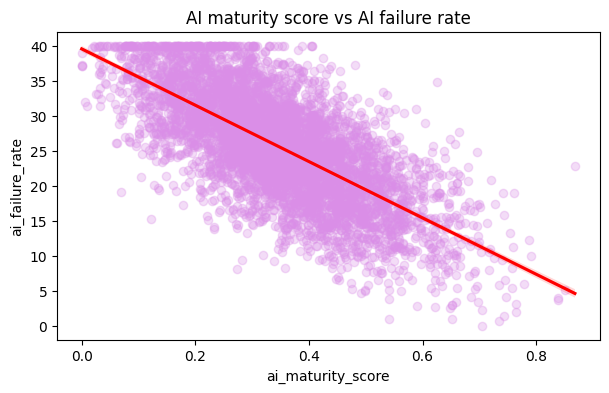

In [43]:
plt.figure(figsize=(7, 4))
# We sample 5000 points so the plot isn't too crowded
df_sample = df.sample(5000) 
sns.regplot(data=df_sample, x='ai_maturity_score', y='ai_failure_rate', 
            scatter_kws={'alpha':0.3}, line_kws={'color':'red'},color="#da8ee7")

plt.title('AI maturity score vs AI failure rate')
plt.show()

# Dimensionality Reduction for target variable

In [44]:
# Applying pca on features = cost_reduction_percent, productivity_change_percent, revenue_growth_percent

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [45]:
target_features = ['cost_reduction_percent', 'productivity_change_percent', 'revenue_growth_percent']
x = df[target_features]

In [46]:
#Standardize the data
x_scaled = StandardScaler().fit_transform(x)

In [47]:
pca = PCA(n_components=1)
principalComponents = pca.fit_transform(x_scaled)

In [48]:
principalComponents

array([[-0.32239117],
       [-1.07883036],
       [ 1.34962927],
       ...,
       [-0.07440403],
       [ 1.63605995],
       [ 2.25872662]], shape=(150000, 1))

In [49]:
df['ROI']=(principalComponents)

In [50]:
df.columns

Index(['company_id', 'industry', 'country', 'company_size',
       'annual_revenue_usd_millions', 'ai_adoption_rate', 'ai_adoption_stage',
       'years_using_ai', 'ai_maturity_score', 'ai_primary_tool',
       'num_ai_tools_used', 'ai_projects_active', 'ai_budget_percentage',
       'ai_failure_rate', 'ai_investment_per_employee',
       'revenue_growth_percent', 'productivity_change_percent',
       'cost_reduction_percent', 'ROI'],
      dtype='object')

In [51]:
df = df.drop(columns = ["revenue_growth_percent","productivity_change_percent","cost_reduction_percent","company_id"])

In [52]:
df.shape

(150000, 15)

# Working with outliers

<Axes: >

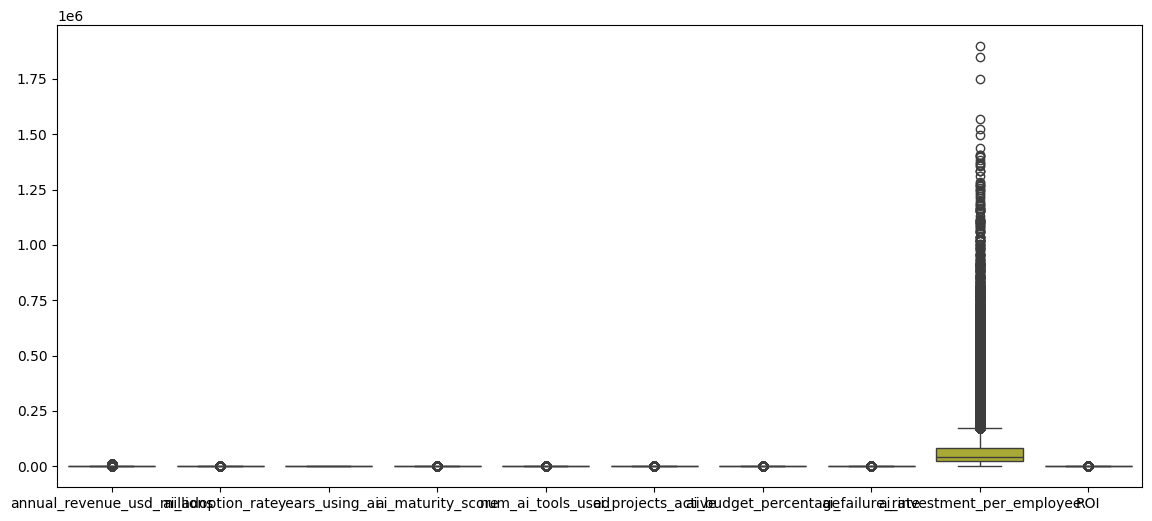

In [53]:
plt.figure(figsize=(14,6))
sns.boxplot(df)

<Axes: >

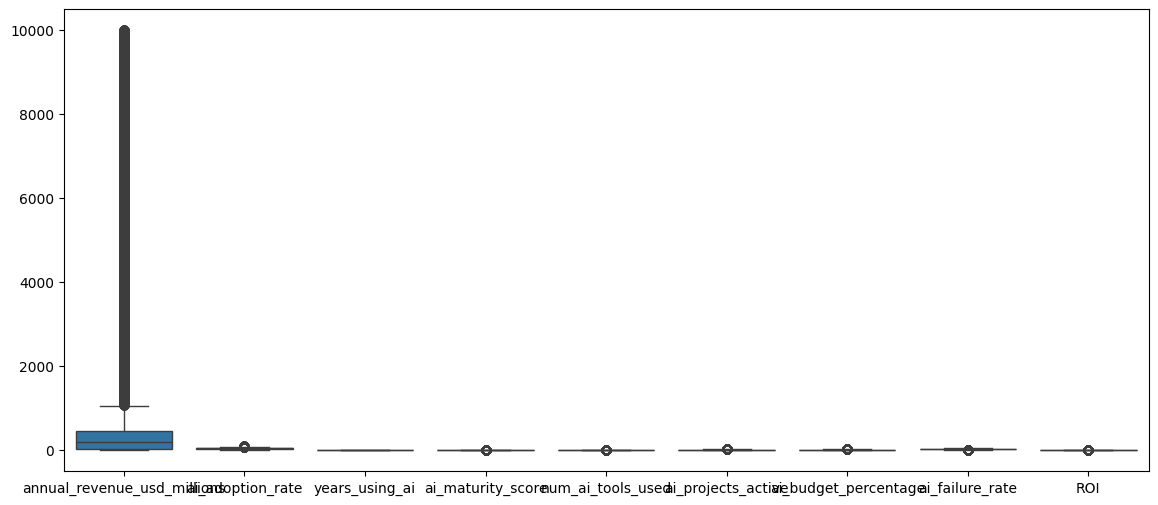

In [54]:
plt.figure(figsize=(14,6))
sns.boxplot(df.drop(columns='ai_investment_per_employee'))

<Axes: >

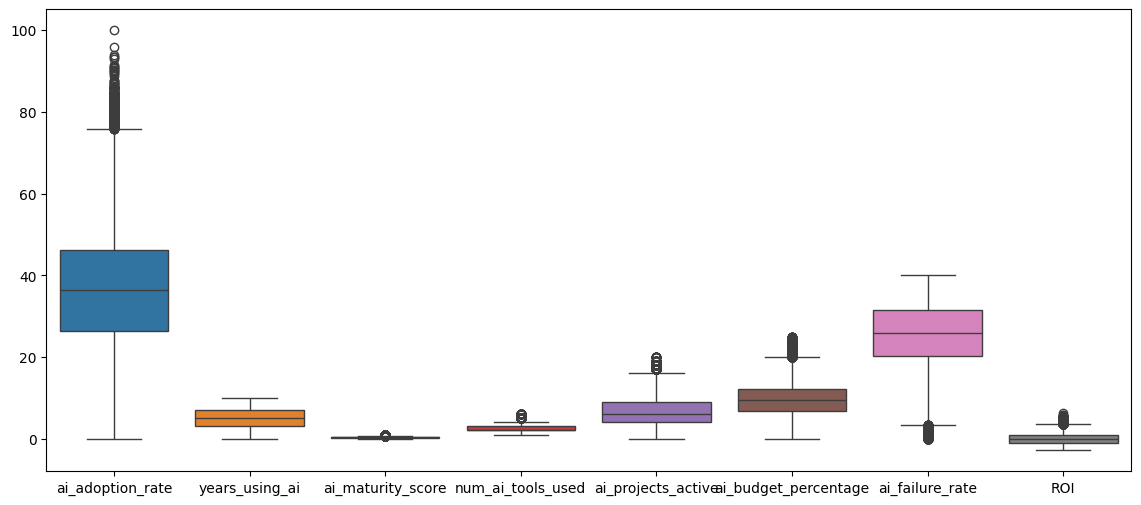

In [55]:
plt.figure(figsize=(14,6))
sns.boxplot(df.drop(columns=['ai_investment_per_employee','annual_revenue_usd_millions']))

<Axes: >

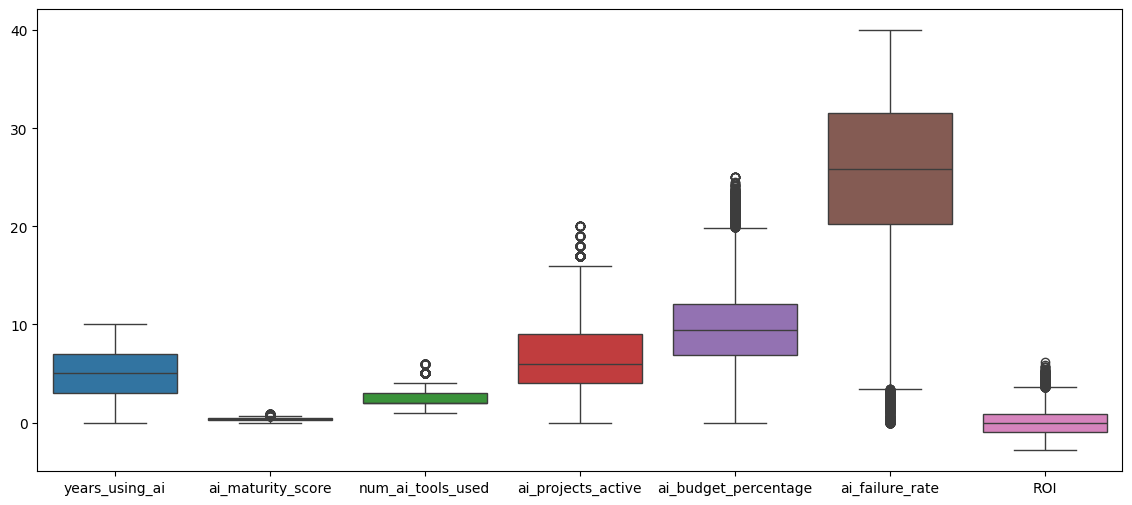

In [56]:
plt.figure(figsize=(14,6))
sns.boxplot(df.drop(columns=['ai_investment_per_employee','annual_revenue_usd_millions','ai_adoption_rate']))

<Axes: >

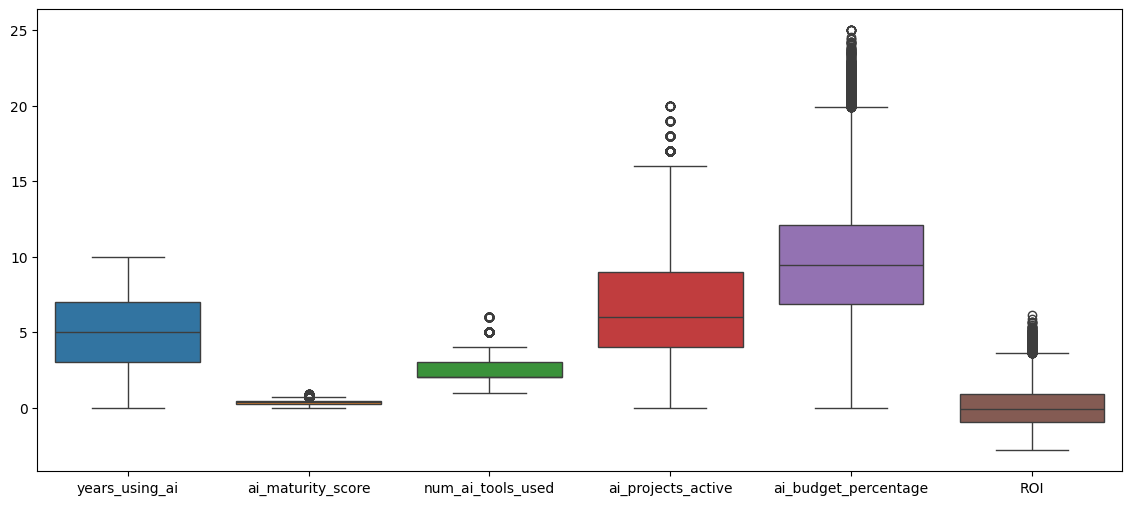

In [57]:
plt.figure(figsize=(14,6))
sns.boxplot(df.drop(columns=['ai_investment_per_employee','annual_revenue_usd_millions','ai_adoption_rate','ai_failure_rate']))

<Axes: >

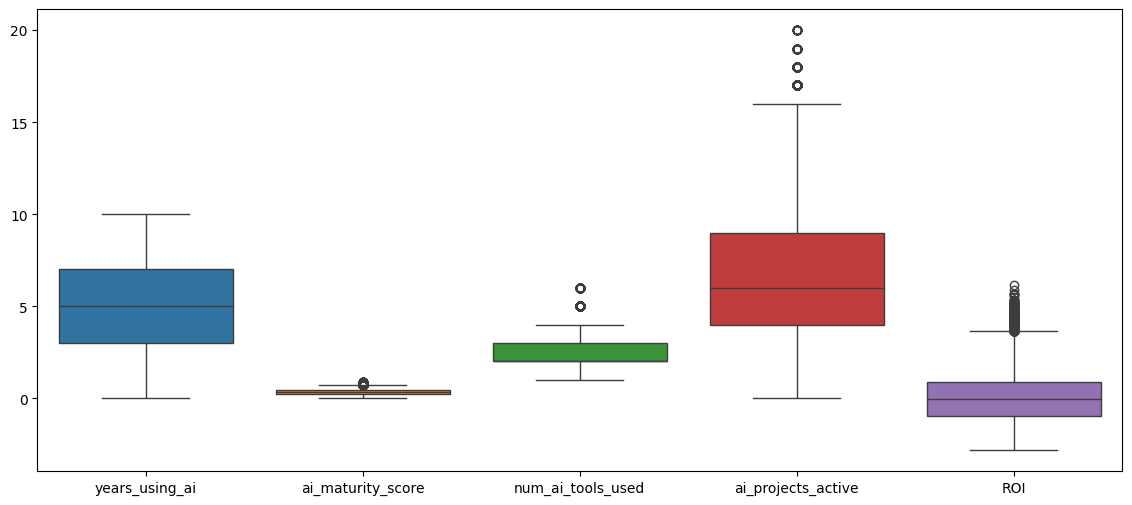

In [58]:
plt.figure(figsize=(14,6))
sns.boxplot(df.drop(columns=['ai_investment_per_employee','annual_revenue_usd_millions',
                             'ai_adoption_rate','ai_failure_rate','ai_budget_percentage']))

<Axes: ylabel='ai_maturity_score'>

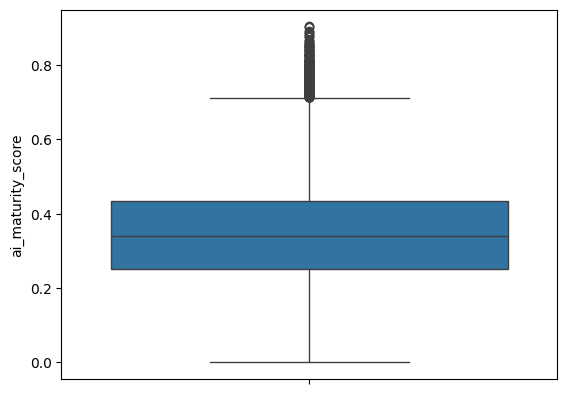

In [59]:
sns.boxplot(df['ai_maturity_score'])

<Axes: ylabel='ai_projects_active'>

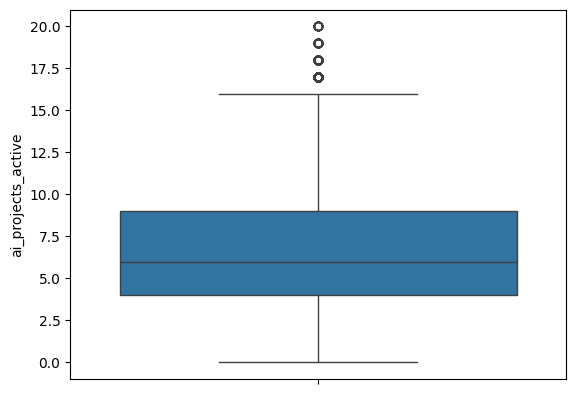

In [60]:
sns.boxplot(df['ai_projects_active'])

<Axes: ylabel='ROI'>

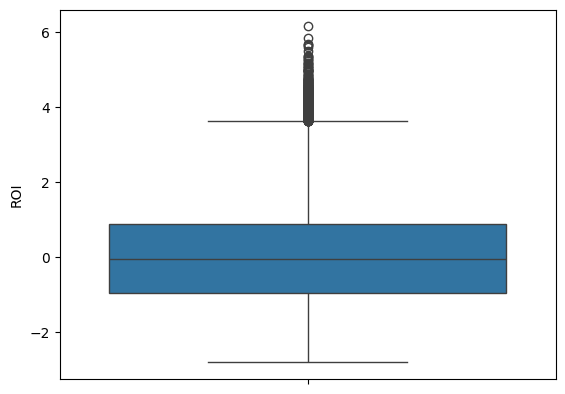

In [61]:
sns.boxplot(df['ROI'])

These columns have high corelation:
'annual_revenue_usd_millions', 'ROI', 'ai_maturity_score', 'ai_budget_percentage'

Applying IQR on some columns : 
'ai_investment_per_employee', 'ai_failure_rate', 'ai_projects_active'


In [62]:
def IQRfunction(df, values):
    # Q1 and Q3
    Q1 = df[values].quantile(0.25)
    Q3 = df[values].quantile(0.75)
    
    # IQR
    IQR = Q3 - Q1
    
    #Bounds
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Removing Outliers
    df_clean = df[(df[values] >= lower_bound) & (df[values] <= upper_bound)]
    
    print("Original Shape:", df.shape)
    print("Cleaned Shape:", df_clean.shape)
    
    return df_clean  


In [63]:
for column in df.select_dtypes(include=['number']).columns:
    df = IQRfunction(df,column)

Original Shape: (150000, 15)
Cleaned Shape: (122053, 15)
Original Shape: (122053, 15)
Cleaned Shape: (121637, 15)
Original Shape: (121637, 15)
Cleaned Shape: (121637, 15)
Original Shape: (121637, 15)
Cleaned Shape: (121310, 15)
Original Shape: (121310, 15)
Cleaned Shape: (120370, 15)
Original Shape: (120370, 15)
Cleaned Shape: (120181, 15)
Original Shape: (120181, 15)
Cleaned Shape: (119857, 15)
Original Shape: (119857, 15)
Cleaned Shape: (119654, 15)
Original Shape: (119654, 15)
Cleaned Shape: (110488, 15)
Original Shape: (110488, 15)
Cleaned Shape: (110101, 15)


<Axes: >

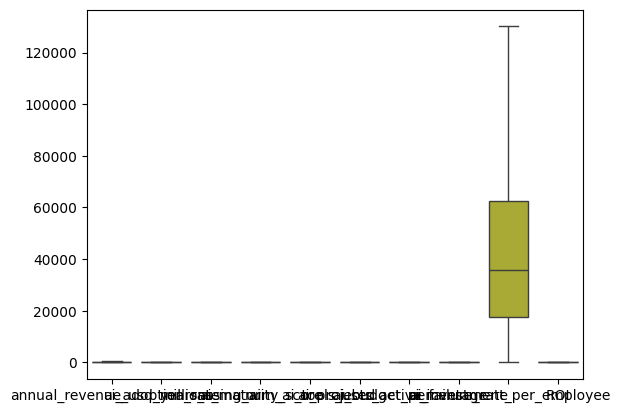

In [64]:
sns.boxplot(data=df, showfliers=False)

<Axes: ylabel='ai_investment_per_employee'>

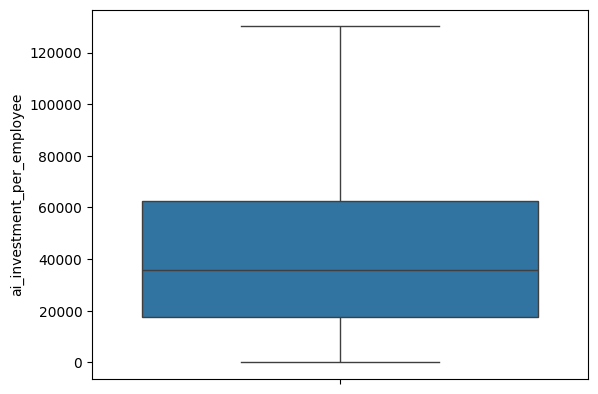

In [65]:
sns.boxplot(df['ai_investment_per_employee'],showfliers=False)

In [66]:
df.shape

(110101, 15)

# Feture Engineering

In [67]:
df.columns

Index(['industry', 'country', 'company_size', 'annual_revenue_usd_millions',
       'ai_adoption_rate', 'ai_adoption_stage', 'years_using_ai',
       'ai_maturity_score', 'ai_primary_tool', 'num_ai_tools_used',
       'ai_projects_active', 'ai_budget_percentage', 'ai_failure_rate',
       'ai_investment_per_employee', 'ROI'],
      dtype='object')

In [68]:
df.shape

(110101, 15)

In [69]:
# selecting top countries only 
top_countries = df["country"].value_counts().nlargest(10).index
df["country"] = df["country"].where(df["country"].isin(top_countries), "Other")


# top industries
top_industries = df['industry'].value_counts().nlargest(5).index

df['industry_grouped'] = df['industry'].apply(
    lambda x: x if x in top_industries else 'Other'
)
df = df.drop(columns=['industry'])

# top ai tool used by companies
df['uses_advanced_ai_tool'] = df['ai_primary_tool'].apply(
    lambda x: 1 if x in ['Custom Internal AI', 'Claude', 'Gemini'] else 0
)
df = df.drop(columns=['ai_primary_tool'])

f_rom here saving the data frame into a new csv file.

So that I can work on it using pipelines fo_r predictions.

In [70]:
df.to_csv("cleaned_ai_adoption_data.csv", index=False)

In [71]:
df['country'].value_counts() # nominal

country
Other          71005
Japan           4186
Germany         4064
South Korea     4020
France          3996
Netherlands     3964
Chile           3949
Kenya           3753
Argentina       3748
Egypt           3724
New Zealand     3692
Name: count, dtype: int64

In [72]:
df['ai_adoption_stage'].value_counts() # ordinal

ai_adoption_stage
pilot      53625
partial    51396
none        4862
full         218
Name: count, dtype: int64

In [73]:
df['company_size'].value_counts() # ordinal

company_size
SME           56964
Startup       51769
Enterprise     1368
Name: count, dtype: int64

Encoding the columns: 

1.industry

2.country

3.company_size

4.ai_adoption_stage

5.ai_primary_tool

In [74]:
df_encoded = df.copy()
from sklearn.preprocessing import OrdinalEncoder

# ordinal encoding
encoder1 = OrdinalEncoder(categories=[["Startup", "SME", "Enterprise"]])
df_encoded["company_size_encoded"] = encoder1.fit_transform(df[["company_size"]])

encoder2 = OrdinalEncoder(categories=[["none", "pilot", "partial", "full"]])
df_encoded["ai_stage_encoded"] = encoder2.fit_transform(df[["ai_adoption_stage"]])

# one hot encoding
df_encoded = pd.get_dummies(df_encoded,columns=["industry_grouped"],drop_first=True) # avoids multicollinearity

# drop original columns
df_encoded = df_encoded.drop(columns=["company_size", "ai_adoption_stage"])

df = df_encoded.copy()
df['country_freq'] = df['country'].map(df['country'].value_counts())
df = df.drop(columns=['country'])

print(df.head())

   annual_revenue_usd_millions  ai_adoption_rate  years_using_ai  \
0                        48.31             30.57               3   
1                        48.31             27.25               4   
2                        48.31             31.54               2   
3                        48.31             11.02               2   
4                        48.31             33.39               7   

   ai_maturity_score  num_ai_tools_used  ai_projects_active  \
0              0.224                  1                   3   
1              0.174                  3                   0   
2              0.266                  3                   3   
3              0.123                  1                   2   
4              0.363                  3                   5   

   ai_budget_percentage  ai_failure_rate  ai_investment_per_employee  \
0                  6.54            35.22                    55392.29   
1                  5.81            24.65                    49210.79

In [75]:
df.head()

,annual_revenue_usd_millions,ai_adoption_rate,years_using_ai,ai_maturity_score,num_ai_tools_used,ai_projects_active,ai_budget_percentage,ai_failure_rate,ai_investment_per_employee,ROI,uses_advanced_ai_tool,company_size_encoded,ai_stage_encoded,industry_grouped_Healthcare,industry_grouped_Manufacturing,industry_grouped_Other,industry_grouped_Retail,industry_grouped_Technology,country_freq
0,48.31,30.57,3,0.224,1,3,6.54,35.22,55392.29,-0.322391,0,0.0,1.0,False,False,True,False,False,71005
1,48.31,27.25,4,0.174,3,0,5.81,24.65,49210.79,-1.078830,0,0.0,1.0,False,False,True,False,False,71005
2,48.31,31.54,2,0.266,3,3,12.39,36.51,105011.76,1.349629,1,0.0,1.0,False,False,True,False,False,71005
3,48.31,11.02,2,0.123,1,2,3.20,33.30,27157.71,-0.755117,1,0.0,1.0,False,False,True,False,False,71005
4,48.31,33.39,7,0.363,3,5,9.98,19.83,84622.90,1.002064,0,0.0,1.0,False,False,True,False,False,71005


In [76]:
df.shape

(110101, 19)

In [77]:
df.isnull().sum()

annual_revenue_usd_millions       0
ai_adoption_rate                  0
years_using_ai                    0
ai_maturity_score                 0
num_ai_tools_used                 0
ai_projects_active                0
ai_budget_percentage              0
ai_failure_rate                   0
ai_investment_per_employee        0
ROI                               0
uses_advanced_ai_tool             0
company_size_encoded              0
ai_stage_encoded                  0
industry_grouped_Healthcare       0
industry_grouped_Manufacturing    0
industry_grouped_Other            0
industry_grouped_Retail           0
industry_grouped_Technology       0
country_freq                      0
dtype: int64

In [78]:
df.columns

Index(['annual_revenue_usd_millions', 'ai_adoption_rate', 'years_using_ai',
       'ai_maturity_score', 'num_ai_tools_used', 'ai_projects_active',
       'ai_budget_percentage', 'ai_failure_rate', 'ai_investment_per_employee',
       'ROI', 'uses_advanced_ai_tool', 'company_size_encoded',
       'ai_stage_encoded', 'industry_grouped_Healthcare',
       'industry_grouped_Manufacturing', 'industry_grouped_Other',
       'industry_grouped_Retail', 'industry_grouped_Technology',
       'country_freq'],
      dtype='object')

Working with features.

In [79]:
df['budget_per_project'] = df['ai_budget_percentage'] / (df['ai_projects_active'] + 1)
df['investment_per_tool'] = df['ai_investment_per_employee'] / (df['num_ai_tools_used'] + 1)

In [80]:
df['success_rate'] = 1 - df['ai_failure_rate']
df['effective_budget'] = df['ai_budget_percentage'] * df['success_rate']

In [81]:
df['maturity_x_adoption'] = df['ai_maturity_score'] * df['ai_adoption_rate']
df['experience_factor'] = df['years_using_ai'] * df['ai_maturity_score']

In [82]:
df['projects_per_tool'] = df['ai_projects_active'] / (df['num_ai_tools_used'] + 1)
df['revenue_per_ai_investment'] = df['annual_revenue_usd_millions'] / (df['ai_investment_per_employee'] + 1)

In [83]:
df.shape

(110101, 27)

In [84]:
df.columns

Index(['annual_revenue_usd_millions', 'ai_adoption_rate', 'years_using_ai',
       'ai_maturity_score', 'num_ai_tools_used', 'ai_projects_active',
       'ai_budget_percentage', 'ai_failure_rate', 'ai_investment_per_employee',
       'ROI', 'uses_advanced_ai_tool', 'company_size_encoded',
       'ai_stage_encoded', 'industry_grouped_Healthcare',
       'industry_grouped_Manufacturing', 'industry_grouped_Other',
       'industry_grouped_Retail', 'industry_grouped_Technology',
       'country_freq', 'budget_per_project', 'investment_per_tool',
       'success_rate', 'effective_budget', 'maturity_x_adoption',
       'experience_factor', 'projects_per_tool', 'revenue_per_ai_investment'],
      dtype='object')

In [85]:
df = df.drop(columns =["ai_budget_percentage","num_ai_tools_used","ai_projects_active","ai_investment_per_employee"])
df.columns

Index(['annual_revenue_usd_millions', 'ai_adoption_rate', 'years_using_ai',
       'ai_maturity_score', 'ai_failure_rate', 'ROI', 'uses_advanced_ai_tool',
       'company_size_encoded', 'ai_stage_encoded',
       'industry_grouped_Healthcare', 'industry_grouped_Manufacturing',
       'industry_grouped_Other', 'industry_grouped_Retail',
       'industry_grouped_Technology', 'country_freq', 'budget_per_project',
       'investment_per_tool', 'success_rate', 'effective_budget',
       'maturity_x_adoption', 'experience_factor', 'projects_per_tool',
       'revenue_per_ai_investment'],
      dtype='object')

In [86]:
df.shape

(110101, 23)

In [87]:
df.head(3)

,annual_revenue_usd_millions,ai_adoption_rate,years_using_ai,ai_maturity_score,ai_failure_rate,ROI,uses_advanced_ai_tool,company_size_encoded,ai_stage_encoded,industry_grouped_Healthcare,...,industry_grouped_Technology,country_freq,budget_per_project,investment_per_tool,success_rate,effective_budget,maturity_x_adoption,experience_factor,projects_per_tool,revenue_per_ai_investment
0,48.31,30.57,3,0.224,35.22,-0.322391,0,0.0,1.0,False,...,False,71005,1.6350,27696.1450,-34.22,-223.7988,6.84768,0.672,1.50,0.000872
1,48.31,27.25,4,0.174,24.65,-1.078830,0,0.0,1.0,False,...,False,71005,5.8100,12302.6975,-23.65,-137.4065,4.74150,0.696,0.00,0.000982
2,48.31,31.54,2,0.266,36.51,1.349629,1,0.0,1.0,False,...,False,71005,3.0975,26252.9400,-35.51,-439.9689,8.38964,0.532,0.75,0.000460


In [88]:
df.shape

(110101, 23)

In [89]:
df.columns

Index(['annual_revenue_usd_millions', 'ai_adoption_rate', 'years_using_ai',
       'ai_maturity_score', 'ai_failure_rate', 'ROI', 'uses_advanced_ai_tool',
       'company_size_encoded', 'ai_stage_encoded',
       'industry_grouped_Healthcare', 'industry_grouped_Manufacturing',
       'industry_grouped_Other', 'industry_grouped_Retail',
       'industry_grouped_Technology', 'country_freq', 'budget_per_project',
       'investment_per_tool', 'success_rate', 'effective_budget',
       'maturity_x_adoption', 'experience_factor', 'projects_per_tool',
       'revenue_per_ai_investment'],
      dtype='object')

# Random Forest 

In [90]:
df.columns

Index(['annual_revenue_usd_millions', 'ai_adoption_rate', 'years_using_ai',
       'ai_maturity_score', 'ai_failure_rate', 'ROI', 'uses_advanced_ai_tool',
       'company_size_encoded', 'ai_stage_encoded',
       'industry_grouped_Healthcare', 'industry_grouped_Manufacturing',
       'industry_grouped_Other', 'industry_grouped_Retail',
       'industry_grouped_Technology', 'country_freq', 'budget_per_project',
       'investment_per_tool', 'success_rate', 'effective_budget',
       'maturity_x_adoption', 'experience_factor', 'projects_per_tool',
       'revenue_per_ai_investment'],
      dtype='object')

In [91]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.model_selection import train_test_split

In [92]:
X = df.drop(columns = "ROI")
y = df["ROI"]

In [93]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [94]:
model = RandomForestRegressor(n_estimators=200,max_depth=8,random_state=42)
model.fit(X_train,y_train)

RandomForestRegressor(max_depth=8, n_estimators=200, random_state=42)

In [95]:
y_pred = model.predict(X_test)

print("R2 Score:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))

R2 Score: 0.4552115634176268
MAE: 0.7153825436605067


In [96]:
importances = model.feature_importances_
feature_importance = pd.DataFrame({'Feature': X_train.columns,
                                   'Random_Forest_Importance': importances}).sort_values(by='Random_Forest_Importance', ascending = False)
feature_importance

,Feature,Random_Forest_Importance
18,maturity_x_adoption,0.949915
3,ai_maturity_score,0.007163
16,success_rate,0.006806
4,ai_failure_rate,0.006416
1,ai_adoption_rate,0.004211
17,effective_budget,0.003952
15,investment_per_tool,0.003708
19,experience_factor,0.003478
21,revenue_per_ai_investment,0.003443
14,budget_per_project,0.003208


In [97]:
 feature_importance["Feature"].head(10)

18          maturity_x_adoption
3             ai_maturity_score
16                 success_rate
4               ai_failure_rate
1              ai_adoption_rate
17             effective_budget
15          investment_per_tool
19            experience_factor
21    revenue_per_ai_investment
14           budget_per_project
Name: Feature, dtype: object

After feature selection through Random forest.

In [98]:
X_train = df[["ai_maturity_score","maturity_x_adoption","success_rate","ai_failure_rate",
              "ai_adoption_rate","effective_budget","investment_per_tool",
              "experience_factor","revenue_per_ai_investment","budget_per_project"]]
y = df["ROI"] 

In [99]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model2 = RandomForestRegressor(n_estimators=200,max_depth=8,random_state=42)
model2.fit(X_train,y_train)

RandomForestRegressor(max_depth=8, n_estimators=200, random_state=42)

In [100]:
y_pred = model2.predict(X_test)

print("R2 Score:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))

R2 Score: 0.4552115634176268
MAE: 0.7153825436605067


# XG Boost

In [101]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error,r2_score

model = XGBRegressor(
    n_estimators=500,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"Root Mean Squared Error: {rmse:.2f}")
print("MAE:", mean_absolute_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

Root Mean Squared Error: 0.89
MAE: 0.7163246296334661
R2 Score: 0.4523905978017688


In [102]:
df.corr(numeric_only=True)['ROI'].sort_values()

ai_failure_rate                  -0.506935
effective_budget                 -0.165449
budget_per_project               -0.120932
revenue_per_ai_investment        -0.059580
industry_grouped_Other           -0.055595
industry_grouped_Healthcare      -0.046700
industry_grouped_Retail          -0.003023
industry_grouped_Manufacturing   -0.001793
uses_advanced_ai_tool            -0.000097
country_freq                      0.013690
annual_revenue_usd_millions       0.046538
company_size_encoded              0.061963
investment_per_tool               0.072704
industry_grouped_Technology       0.109852
years_using_ai                    0.129871
projects_per_tool                 0.309264
experience_factor                 0.437493
success_rate                      0.506935
ai_stage_encoded                  0.548901
ai_adoption_rate                  0.632384
ai_maturity_score                 0.653101
maturity_x_adoption               0.662003
ROI                               1.000000
Name: ROI, 

In [103]:
X = df[[
    'ai_adoption_rate',
    'ai_maturity_score',
    'maturity_x_adoption',
    'projects_per_tool',
    'experience_factor',
    'success_rate',
    'ai_stage_encoded',
    'years_using_ai'
]]

y = df['ROI']

In [104]:
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"Root Mean Squared Error: {rmse:.2f}")
print("MAE:", mean_absolute_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

Root Mean Squared Error: 0.89
MAE: 0.7163246296334661
R2 Score: 0.4523905978017688


# The model achieved an R² of around 0.45
I validated multiple algorithms including Random Forest and XGBoost.
The performance plateaued across models, which indicates that the limitation is not in the model but in the data signal strength.

The R² of ~0.45 is primarily due to missing real-world causal drivers of ROI such as execution quality,
organizational readiness, market conditions, leadership quality,project management efficiency,implementation speed
market demand employee AI literacy, training investment. These factors are typically not 
captured in structured datasets but significantly influence ROI outcomes.

In this project, ROI was derived using PCA from cost reduction, productivity change,
and revenue growth metrics. Since PCA compresses multiple correlated performance indicators into a single latent variable,
some information loss is expected.

PCA was used only to construct a unified ROI proxy from correlated performance metrics 
like cost reduction, productivity change, and revenue growth. It helped simplify the target but does not fundamentally limit predictive performance.

As a result, the model’s R² plateaued around 0.45 even after using advanced models like
XGBoost and Random Forest, indicating that the remaining variance is not fully explained by available features.